Installing CatBoost

In [20]:
pip install catboost

Imports & Setup

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

pd.set_option('display.max_columns', None)
np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


Load Data

In [22]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Sample shape:", sample.shape)

train.head()

Train shape: (6818, 13)
Test shape : (1705, 12)
Sample shape: (1705, 2)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


Exploratory Data Analysis

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB

Missing values in train:
product_weight_kg    1225
store_size     

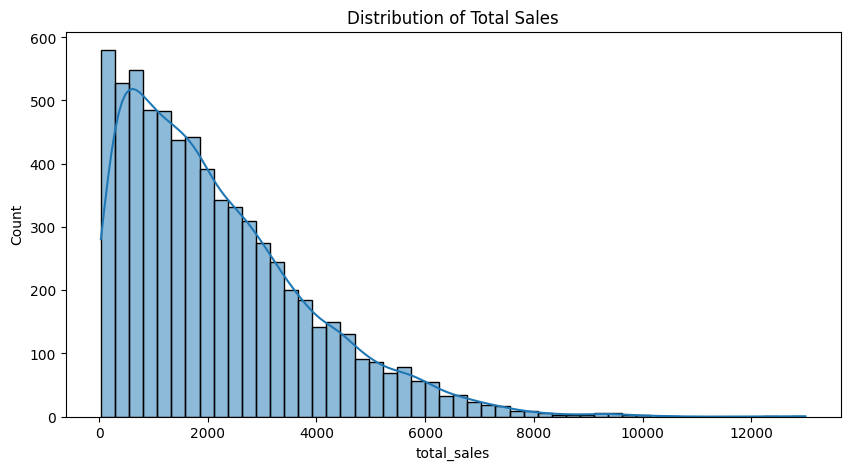

In [23]:
print("Train info:")
train.info()
print("\nMissing values in train:")
print(train.isnull().sum()[train.isnull().sum() > 0])
print("\nMissing values in test:")
print(test.isnull().sum()[test.isnull().sum() > 0])

print("\nTarget stats:")
print(train['total_sales'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(train['total_sales'], bins=50, kde=True)
plt.title('Distribution of Total Sales')
plt.show()

Target Transformation Check

Skewness (raw): 1.1539947519138116
Skewness (log): -0.8951280115081985


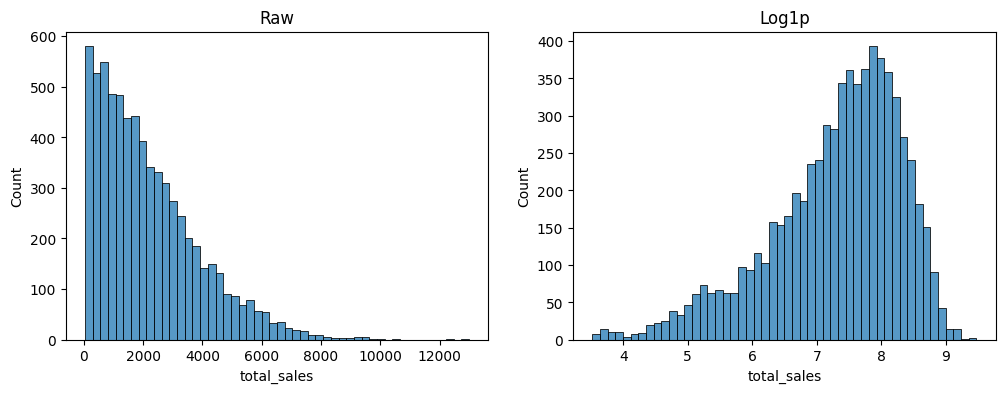

In [24]:
print("Skewness (raw):", train['total_sales'].skew())
print("Skewness (log):", np.log1p(train['total_sales']).skew())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(train['total_sales'], bins=50); plt.title('Raw')
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train['total_sales']), bins=50); plt.title('Log1p')
plt.show()

Combine Train & Test for Consistent Encoding

In [25]:
target = 'total_sales'
train['is_train'] = 1
test['is_train'] = 0
test[target] = np.nan

full = pd.concat([train, test], axis=0, ignore_index=True)
print("Combined shape:", full.shape)

Combined shape: (8523, 14)


Clean Categorical Text (Case/Whitespace Inconsistencies)

The data has messy category strings like "Frozen Foods", "frozen foods", "FROZEN FOODS". They need to be normalized.

In [26]:
cat_cols = ['product_category', 'fat_content', 'store_size',
            'store_location_tier', 'store_format']

for col in cat_cols:
    full[col] = (full[col]
                 .astype(str)
                 .str.strip()
                 .str.lower()
                 .replace({'nan': np.nan}))

print("Unique product categories:", full['product_category'].nunique())
print(sorted(full['product_category'].dropna().unique()))

Unique product categories: 16
['baking goods', 'breads', 'breakfast', 'canned', 'dairy', 'frozen foods', 'fruits and vegetables', 'hard drinks', 'health and hygiene', 'household', 'meat', 'others', 'seafood', 'snack foods', 'soft drinks', 'starchy foods']


Feature Engineering: Product & Store Aggregates

In [27]:
# Price per kg (product weight is sometimes missing)
full['price_per_kg'] = full['product_price'] / full['product_weight_kg']
full['price_per_kg'] = full['price_per_kg'].replace([np.inf, -np.inf], np.nan)

# Product-level statistics (computed on train-only to avoid leakage in aggregates)
train_only = full[full['is_train'] == 1]

prod_stats = train_only.groupby('product_code')[target].agg(
    ['mean', 'std', 'median', 'min', 'max', 'count']
).rename(columns=lambda c: f'prod_{c}')

store_stats = train_only.groupby('store_code')[target].agg(
    ['mean', 'std', 'median', 'count']
).rename(columns=lambda c: f'store_{c}')

prod_cat_stats = train_only.groupby('product_category')[target].agg(
    ['mean', 'std']
).rename(columns=lambda c: f'pcat_{c}')

store_fmt_stats = train_only.groupby('store_format')[target].agg(
    ['mean', 'std']
).rename(columns=lambda c: f'sfmt_{c}')

full = full.merge(prod_stats, on='product_code', how='left')
full = full.merge(store_stats, on='store_code', how='left')
full = full.merge(prod_cat_stats, on='product_category', how='left')
full = full.merge(store_fmt_stats, on='store_format', how='left')

print("After aggregate merge:", full.shape)

After aggregate merge: (8523, 29)


 Interaction & Ratio Features

In [28]:
full['visibility_x_price'] = full['shelf_visibility'] * full['product_price']
full['weight_x_price']     = full['product_weight_kg'] * full['product_price']
full['age_x_visibility']   = full['store_age_years'] * full['shelf_visibility']

full['prod_store_mean'] = full.groupby(['product_code', 'store_code'])[target].transform('mean')

full['price_vs_cat_mean']   = full['product_price'] - full.groupby('product_category')['product_price'].transform('mean')
full['weight_vs_cat_mean']  = full['product_weight_kg'] - full.groupby('product_category')['product_weight_kg'].transform('mean')
full['visibility_vs_cat']   = full['shelf_visibility'] - full.groupby('product_category')['shelf_visibility'].transform('mean')

print("Feature engineering complete. Shape:", full.shape)

Feature engineering complete. Shape: (8523, 36)


Encode Categoricals

In [29]:
from sklearn.preprocessing import OrdinalEncoder

encode_cols = ['product_code', 'store_code', 'product_category',
               'fat_content', 'store_size', 'store_location_tier', 'store_format']

for col in encode_cols:
    full[col] = full[col].astype(str)
    le = LabelEncoder()
    full[col + '_enc'] = le.fit_transform(full[col])

full.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,is_train,price_per_kg,prod_mean,prod_std,prod_median,prod_min,prod_max,prod_count,store_mean,store_std,store_median,store_count,pcat_mean,pcat_std,sfmt_mean,sfmt_std,visibility_x_price,weight_x_price,age_x_visibility,prod_store_mean,price_vs_cat_mean,weight_vs_cat_mean,visibility_vs_cat,product_code_enc,store_code_enc,product_category_enc,fat_content_enc,store_size_enc,store_location_tier_enc,store_format_enc
0,row_00000,PRD-PRFP9S,14.252,low fat,0.0271,frozen foods,81.37,STORE-AGY,45,large,tier_3,standard supermarket,1764.98,1,5.709374,1358.816000,495.381362,1324.73,795.93,1944.34,5.0,2254.890120,1501.401983,1998.725,748,2140.770133,1755.669731,2316.319677,1515.508566,2.205127,1159.68524,1.2195,1764.98,-57.230864,1.403461,-0.038665,1126,3,5,0,0,2,2
1,row_00001,PRD-PXXK71,7.698,low fat,0.0720,health and hygiene,42.05,STORE-YLW,35,small,tier_1,standard supermarket,342.13,1,5.462458,1076.154000,593.535576,1039.34,342.13,1967.00,5.0,2253.950690,1488.222137,1902.455,754,1996.266044,1557.335133,2316.319677,1515.508566,3.027600,323.70090,2.5200,342.13,-88.761635,-5.397685,0.016847,1135,9,8,0,3,0,2
2,row_00002,PRD-V5MOIJ,14.264,regular,0.0421,canned,41.35,STORE-89Z,33,medium,tier_1,standard supermarket,378.85,1,2.898906,412.431667,410.193089,297.51,41.63,1164.65,6.0,2365.926745,1518.177714,2003.490,728,2196.398743,1618.732859,2316.319677,1515.508566,1.740835,589.81640,1.3893,378.85,-98.370924,1.922637,-0.025905,1368,1,3,1,1,0,2
3,row_00003,PRD-UN5Z3J,NaN,regular,0.0449,soft drinks,174.35,STORE-7WS,47,medium,tier_3,flagship hypermarket,5595.72,1,NaN,3334.792500,2063.818021,3233.69,1276.07,5595.72,4.0,3660.182219,2070.097702,3348.085,748,1967.399454,1726.930847,3660.182219,2070.097702,7.828315,NaN,2.1103,5595.72,42.775820,NaN,-0.019044,1337,0,14,1,1,2,1
4,row_00004,PRD-6RDQYB,10.338,regular,0.0120,meat,203.06,STORE-9RG,28,small,tier_2,standard supermarket,2375.36,1,19.642097,2047.210000,998.046086,2494.48,560.78,2639.10,4.0,2479.168098,1553.797046,2139.320,752,2264.310383,1759.505669,2316.319677,1515.508566,2.436720,2099.23428,0.3360,2375.36,63.183788,-2.483540,-0.050442,327,2,10,1,3,1,2


Handle Missing Values

In [30]:
num_cols = full.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in [target, 'is_train']]

# Fill numeric NaNs with median
for col in num_cols:
    if full[col].isnull().any():
        full[col] = full[col].fillna(full[col].median())

print("Remaining nulls:", full[num_cols].isnull().sum().sum())

Remaining nulls: 0


Build Final Train/Test Feature Sets

In [31]:
feature_cols = [c for c in full.columns
                if c not in ['id', target, 'is_train']
                and full[c].dtype != 'object']

print(f"Number of features: {len(feature_cols)}")
print(feature_cols)

X_train = full.loc[full['is_train'] == 1, feature_cols].reset_index(drop=True)
y_train = full.loc[full['is_train'] == 1, target].reset_index(drop=True)
X_test  = full.loc[full['is_train'] == 0, feature_cols].reset_index(drop=True)
test_ids = full.loc[full['is_train'] == 0, 'id'].reset_index(drop=True)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

Number of features: 33
['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'price_per_kg', 'prod_mean', 'prod_std', 'prod_median', 'prod_min', 'prod_max', 'prod_count', 'store_mean', 'store_std', 'store_median', 'store_count', 'pcat_mean', 'pcat_std', 'sfmt_mean', 'sfmt_std', 'visibility_x_price', 'weight_x_price', 'age_x_visibility', 'prod_store_mean', 'price_vs_cat_mean', 'weight_vs_cat_mean', 'visibility_vs_cat', 'product_code_enc', 'store_code_enc', 'product_category_enc', 'fat_content_enc', 'store_size_enc', 'store_location_tier_enc', 'store_format_enc']
X_train: (6818, 33) | X_test: (1705, 33)


Log-Transform Target

In [32]:
y_log = np.log1p(y_train)
print("y_log skew:", y_log.skew())

y_log skew: -0.8951280115081985


Model Comparison (5-Fold CV)

In [33]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(max_depth=12, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=300, max_depth=14,
                                               n_jobs=-1, random_state=42),
    'Extra Trees':       ExtraTreesRegressor(n_estimators=300, max_depth=14,
                                             n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=5,
                                                   learning_rate=0.05, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=500, max_depth=7, learning_rate=0.05,
                                      subsample=0.8, colsample_bytree=0.8,
                                      random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM':          LGBMRegressor(n_estimators=600, max_depth=8, learning_rate=0.05,
                                       subsample=0.8, colsample_bytree=0.8,
                                       random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost':          CatBoostRegressor(iterations=600, depth=7, learning_rate=0.05,
                                           random_seed=42, verbose=0),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_log,
                             cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_scores = -scores
    results[name] = (rmse_scores.mean(), rmse_scores.std())
    print(f"{name:20s}  RMSE(log): {rmse_scores.mean():.4f}  ± {rmse_scores.std():.4f}")

results_df = pd.DataFrame(results, index=['RMSE_mean', 'RMSE_std']).T.sort_values('RMSE_mean')
print("\n--- Leaderboard ---")
print(results_df)

Linear Regression     RMSE(log): 0.3593  ± 0.0156
Ridge                 RMSE(log): 0.3593  ± 0.0156
Decision Tree         RMSE(log): 0.0069  ± 0.0019
Random Forest         RMSE(log): 0.0050  ± 0.0013
Extra Trees           RMSE(log): 0.0109  ± 0.0060
Gradient Boosting     RMSE(log): 0.0024  ± 0.0007
XGBoost               RMSE(log): 0.0321  ± 0.0029
LightGBM              RMSE(log): 0.0263  ± 0.0039
CatBoost              RMSE(log): 0.0216  ± 0.0037

--- Leaderboard ---
                   RMSE_mean  RMSE_std
Gradient Boosting   0.002427  0.000697
Random Forest       0.004997  0.001308
Decision Tree       0.006945  0.001916
Extra Trees         0.010894  0.005970
CatBoost            0.021633  0.003717
LightGBM            0.026314  0.003945
XGBoost             0.032149  0.002888
Ridge               0.359274  0.015641
Linear Regression   0.359295  0.015618


Train Best Models & Generate Predictions

In [ ]:
best_models = {
    'XGBoost':  XGBRegressor(n_estimators=800, max_depth=8, learning_rate=0.03,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=1000, max_depth=9, learning_rate=0.03,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=1000, depth=8, learning_rate=0.03,
                                  random_seed=42, verbose=0),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=500, max_depth=16,
                                      n_jobs=-1, random_state=42),
}

preds_log = {}
for name, model in best_models.items():
    model.fit(X_train, y_log)
    preds_log[name] = model.predict(X_test)
    print(f"{name} trained and predicted.")

XGBoost trained and predicted.
LightGBM trained and predicted.


Ensemble (Weighted Average)

In [ ]:
# Simple average of log predictions, then expm1
pred_log_avg = np.mean([preds_log[n] for n in preds_log], axis=0)
pred_final = np.expm1(pred_log_avg)

# Sanity check
print("Prediction stats:")
print(pd.Series(pred_final).describe())
print("\nTrain target stats:")
print(y_train.describe())

Feature Importance (from LightGBM)

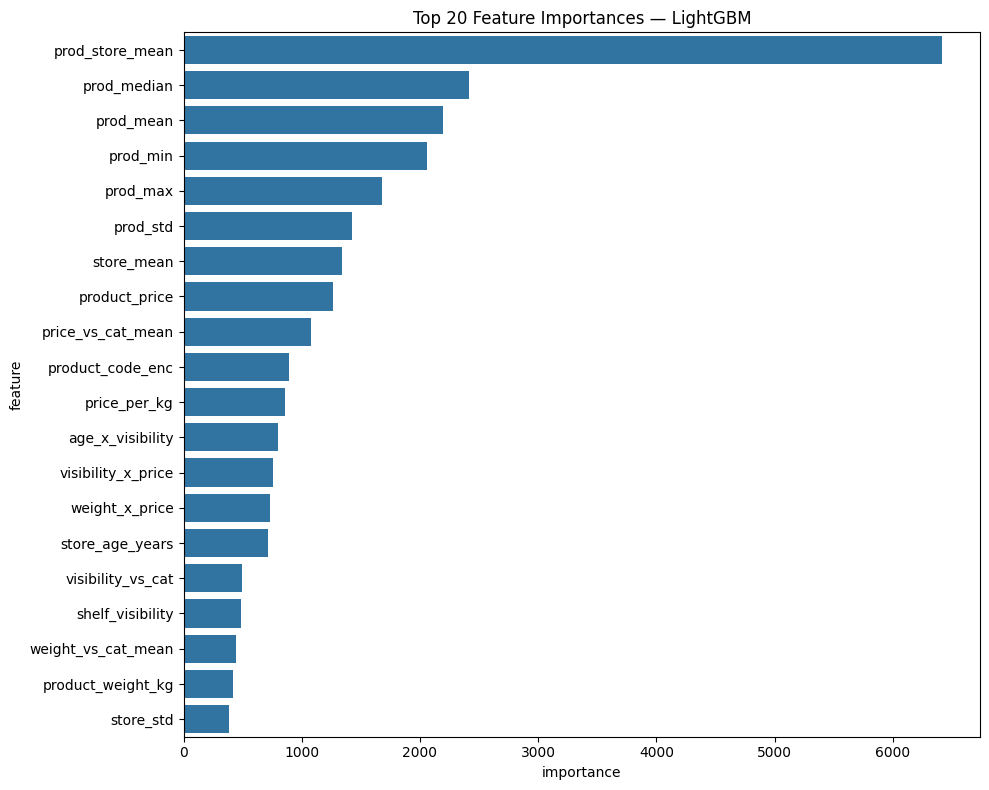

               feature  importance
22     prod_store_mean        6418
7          prod_median        2418
5            prod_mean        2193
8             prod_min        2056
9             prod_max        1682
6             prod_std        1427
11          store_mean        1337
2        product_price        1260
23   price_vs_cat_mean        1077
26    product_code_enc         894
4         price_per_kg         859
21    age_x_visibility         796
19  visibility_x_price         760
20      weight_x_price         733
3      store_age_years         717
25   visibility_vs_cat         497
1     shelf_visibility         486
24  weight_vs_cat_mean         441
0    product_weight_kg         416
12           store_std         383


In [35]:
lgb_model = best_models['LightGBM']
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importances — LightGBM')
plt.tight_layout()
plt.show()

print(importance.head(20))

Generate Submission

In [36]:
submission = pd.DataFrame({
    'id': test_ids,
    'total_sales': pred_final
})

# Ensure the submission order matches sample_submission
submission = sample[['id']].merge(submission, on='id', how='left')
submission['total_sales'] = submission['total_sales'].fillna(submission['total_sales'].median())

submission.to_csv('submission.csv', index=False)
print("Saved submission.csv")
print(submission.head())
print("\nSubmission shape:", submission.shape)

Saved submission.csv
          id  total_sales
0  row_00009  1796.681967
1  row_00015  1801.810135
2  row_00019  1812.376897
3  row_00020  1800.546501
4  row_00023  1785.597824

Submission shape: (1705, 2)


Quick Prediction Sanity vs Sample Baseline

Sample baseline mean: 2174.760000000001
Prediction mean : 1742.7602889448078

Correlation of predictions with row id (should be ~random): 0.011458432872941642


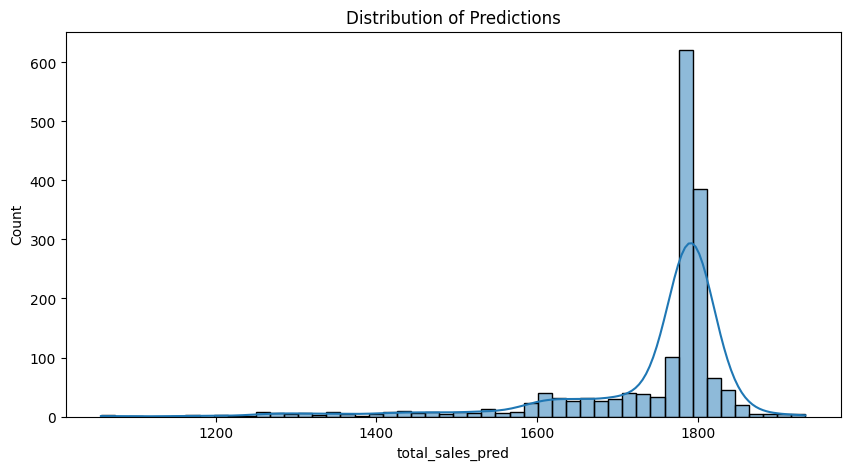

In [37]:
sample_check = pd.read_csv('sample_submission.csv')
merged = sample_check.merge(submission, on='id', suffixes=('_sample', '_pred'))

print("Sample baseline mean:", merged['total_sales_sample'].mean())
print("Prediction mean :", merged['total_sales_pred'].mean())
print("\nCorrelation of predictions with row id (should be ~random):",
      merged['total_sales_pred'].corr(pd.Series(range(len(merged)))))

plt.figure(figsize=(10, 5))
sns.histplot(merged['total_sales_pred'], bins=50, kde=True)
plt.title('Distribution of Predictions')
plt.show()